# Synthetic KRR: dense solve / Richardson / preconditioned Richardson / EFGP

这个 notebook 针对下面的 synthetic regression：

- `x_i ~ Unif([0, 1]^d)`, `d in {1, 2, 3}`
- `f_*(x) = cos(2 pi <x, omega> + 1.3)`
- `y_i = f_*(x_i) + epsilon_i`, `epsilon_i ~ N(0, sigma^2)`

并且只使用 `gpu_benchmark_datasets.ipynb` 里给出的两个 kernel：

- `mat32_ls0.1`
- `gaussian_ls0.1`

输出 6 张图：

1. direct solve 下，求解时间 vs `N`（5 个点）
2. 最大 `N` 下，direct solve vs Richardson 耗时
3. 最大 `N` 下，`A = K + lambda I` 的 PSD 谱
4. 最大 `N` 下，Richardson vs preconditioned Richardson 耗时
5. 最大 `N` 下，`P A` 的 PSD 谱，并与 `A` 对比
6. 最大 `N` 下，dense Richardson vs EFGP 后的 Richardson：solve time / iteration 数 / iteration cost

说明：前 5 张图用的是 dense sample-space KRR；第 6 张图复用 `EFGPSolver` 做 EFGP 权重空间近似。为了让 `d=3` 的 EFGP 网格规模可运行，下面单独把 `EFGP_EPS` 设得比主 benchmark 更保守。

In [72]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _resolve_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "efgp_eigenpro_py").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing 'efgp_eigenpro_py'.")


REPO_ROOT = _resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.eigenpro_precond import build_preconditioner
from efgp_eigenpro_py.eigenspace import estimate_top_eigenspace
from efgp_eigenpro_py.kernels import make_matern, make_squared_exponential
from efgp_eigenpro_py.linear_solvers import richardson

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: D:\NU\ML


In [73]:
'''
    {
        "name": "mat32_ls0.1",
        "family": "matern",
        "nu": 1.5,
        "lengthscale": 0.1,
        "variance": 1.0,
    },
'''

'\n    {\n        "name": "mat32_ls0.1",\n        "family": "matern",\n        "nu": 1.5,\n        "lengthscale": 0.1,\n        "variance": 1.0,\n    },\n'

In [74]:
KERNEL_SPECS = [
    {
        "name": "gaussian_ls0.1",
        "family": "gaussian",
        "lengthscale": 0.1,
        "variance": 1.0,
    }
]

DIM_LIST = [3]
N_LIST = [128, 256, 512,1024,1536,2560,3072,4096]
MAX_N = max(N_LIST)
NOISE_STD = 0.05
REG_LAMBDA = 0.1
DIRECT_REPEATS = 3
RICHARDSON_TOL = 1e-6
RICHARDSON_MAXITER = 100000
PRECOND_TOP_Q = 64

# EFGP 这里单独取更保守的 eps，这样 d=3 / Matern 的 M 不会过大。
EFGP_EPS = 1e-2
EFGP_NUFFT_TOL = 1e-10
EFGP_L2_SCALED = True
EFGP_LAMBDA_EST_METHOD = "subspace_iter"
EFGP_LAMBDA_EST_MAXITER = 4

GLOBAL_SEED = 20260511


def omega_for_dim(dim: int) -> np.ndarray:
    omega = np.arange(1, dim + 1, dtype=np.float64)
    omega /= np.linalg.norm(omega)
    return omega


def kernel_label(kernel_cfg: dict) -> str:
    family = str(kernel_cfg["family"]).strip().lower()
    if family == "matern":
        return f"Matern nu={kernel_cfg['nu']}, l={kernel_cfg['lengthscale']}"
    return f"Gaussian l={kernel_cfg['lengthscale']}"


print("DIM_LIST:", DIM_LIST)
print("N_LIST:", N_LIST)
print("REG_LAMBDA:", REG_LAMBDA)
print("EFGP_EPS:", EFGP_EPS)

DIM_LIST: [3]
N_LIST: [128, 256, 512, 1024, 1536, 2560, 3072, 4096]
REG_LAMBDA: 0.1
EFGP_EPS: 0.01


In [75]:
def make_kernel_from_cfg(kernel_cfg: dict, dim: int):
    family = str(kernel_cfg.get("family", "matern")).strip().lower()
    lengthscale = float(kernel_cfg["lengthscale"])
    variance = float(kernel_cfg.get("variance", 1.0))
    if family in {"matern", "mat", "mat32", "mat52"}:
        nu = float(kernel_cfg.get("nu", 1.5))
        return make_matern(lengthscale=lengthscale, nu=nu, dim=int(dim), variance=variance)
    if family in {"gaussian", "rbf", "se", "squared_exponential", "squared-exponential"}:
        return make_squared_exponential(lengthscale=lengthscale, dim=int(dim), variance=variance)
    raise ValueError(f"Unsupported kernel family: {family}")


def target_function(x: np.ndarray, omega: np.ndarray, phase: float = 1.3) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    return np.cos(2.0 * np.pi * (x @ omega) + float(phase))


def generate_nested_dataset(dim: int, n_max: int, noise_std: float, seed: int) -> dict:
    rng = np.random.default_rng(int(seed))
    omega = omega_for_dim(dim)
    x_train = rng.uniform(0.0, 1.0, size=(int(n_max), int(dim)))
    y_true = target_function(x_train, omega)
    y_train = y_true + rng.normal(0.0, float(noise_std), size=int(n_max))
    return {
        "dim": int(dim),
        "omega": omega,
        "x_train": np.asarray(x_train, dtype=np.float64),
        "y_train": np.asarray(y_train, dtype=np.float64),
        "y_true": np.asarray(y_true, dtype=np.float64),
    }


def pairwise_distance_matrix(x1: np.ndarray, x2: np.ndarray | None = None) -> np.ndarray:
    x1 = np.asarray(x1, dtype=np.float64)
    x2 = x1 if x2 is None else np.asarray(x2, dtype=np.float64)
    diff = x1[:, None, :] - x2[None, :, :]
    return np.linalg.norm(diff, axis=-1)


def build_dense_krr_system(
    x_train: np.ndarray,
    y_train: np.ndarray,
    kernel_cfg: dict,
    reg_lambda: float,
) -> tuple[object, np.ndarray, np.ndarray, np.ndarray]:
    kernel = make_kernel_from_cfg(kernel_cfg, x_train.shape[1])
    K = np.asarray(kernel.k(pairwise_distance_matrix(x_train)), dtype=np.float64)
    A = K + float(reg_lambda) * np.eye(x_train.shape[0], dtype=np.float64)
    b = np.asarray(y_train, dtype=np.float64).reshape(-1)
    return kernel, K, A, b


def timed_direct_solve(A: np.ndarray, b: np.ndarray) -> dict:
    t0 = time.perf_counter()
    alpha = np.linalg.solve(A, b)
    t1 = time.perf_counter()
    relres = np.linalg.norm(A @ alpha - b) / max(np.linalg.norm(b), 1e-12)
    return {
        "alpha": alpha,
        "time_s": float(t1 - t0),
        "relres": float(relres),
    }


def richardson_eta_from_lambda_max(lambda_max: float, safety: float = 0.9) -> float:
    return float(safety) / max(float(lambda_max), 1e-12)


def as_axes_2d(axes, nrows: int, ncols: int) -> np.ndarray:
    axes_arr = np.asarray(axes, dtype=object)
    if axes_arr.ndim == 0:
        return axes_arr.reshape(1, 1)
    if axes_arr.ndim == 1:
        if int(nrows) == 1:
            return axes_arr.reshape(1, int(ncols))
        if int(ncols) == 1:
            return axes_arr.reshape(int(nrows), 1)
    return axes_arr


def subplot_figsize(
    nrows: int,
    ncols: int,
    *,
    width_per_col: float = 5.6,
    height_per_row: float = 3.5,
    min_width: float = 6.5,
    min_height: float = 3.8,
    max_width: float = 16.0,
    max_height: float = 24.0,
) -> tuple[float, float]:
    width = min(max(float(ncols) * width_per_col, min_width), max_width)
    height = min(max(float(nrows) * height_per_row, min_height), max_height)
    return width, height


def run_dense_richardson_case(
    A: np.ndarray,
    b: np.ndarray,
    lambda_max_effective: float,
    *,
    precond=None,
) -> dict:
    eta = richardson_eta_from_lambda_max(lambda_max_effective)
    x0 = np.zeros_like(b)
    t0 = time.perf_counter()
    alpha, iters, relres = richardson(
        lambda v: A @ v,
        b,
        x0,
        eta=eta,
        tol=RICHARDSON_TOL,
        maxiter=RICHARDSON_MAXITER,
        precond=precond,
    )
    t1 = time.perf_counter()
    return {
        "alpha": alpha,
        "eta": float(eta),
        "iters": int(iters),
        "relres": float(relres),
        "time_s": float(t1 - t0),
    }


def build_dense_eigenpro_preconditioner(
    A: np.ndarray,
    eigvals_desc: np.ndarray,
    eigvecs_desc: np.ndarray,
    top_q: int,
) -> tuple[object, np.ndarray, np.ndarray, int]:
    n = int(eigvals_desc.size)
    q = max(1, min(int(top_q), n - 1))
    theta = np.asarray(eigvals_desc[:q], dtype=np.float64)
    U = np.asarray(eigvecs_desc[:, :q], dtype=np.float64)
    mu = float(eigvals_desc[q])
    precond = build_preconditioner(theta, U, mu)
    scale = 1.0 - (mu / theta)
    P = np.eye(n, dtype=np.float64) - U @ (scale[:, None] * U.T)
    PA_dense = 0.5 * ((P @ A) + (A @ P))
    pa_eigvals = np.linalg.eigvalsh(PA_dense)[::-1]
    return precond, P, np.asarray(pa_eigvals, dtype=np.float64), q


def estimate_efgp_lambda_max(solver: EFGPSolver, state) -> float:
    eigpairs = estimate_top_eigenspace(
        lambda v: solver._apply_A(state, v),
        size=int(state.rhs.size),
        top_q=1,
        method=EFGP_LAMBDA_EST_METHOD,
        maxiter=EFGP_LAMBDA_EST_MAXITER,
        matvec_block=lambda V: solver._apply_A_block(state, V),
        block_size=4,
        oversample=1,
    )
    return float(np.real(eigpairs.values[0]))


def run_efgp_richardson_case(x_train: np.ndarray, y_train: np.ndarray, kernel_cfg: dict) -> dict:
    kernel = make_kernel_from_cfg(kernel_cfg, x_train.shape[1])
    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EFGP_EPS,
        nufft_tol=EFGP_NUFFT_TOL,
        l2scaled=EFGP_L2_SCALED,
    )

    t0 = time.perf_counter()
    state = solver.precompute(x_train, y_train)
    t1 = time.perf_counter()

    lambda_max = estimate_efgp_lambda_max(solver, state)
    eta = richardson_eta_from_lambda_max(lambda_max)
    beta0 = np.zeros_like(state.rhs)

    t2 = time.perf_counter()
    beta, iters, relres = richardson(
        lambda v: solver._apply_A(state, v),
        state.rhs,
        beta0,
        eta=eta,
        tol=RICHARDSON_TOL,
        maxiter=RICHARDSON_MAXITER,
    )
    t3 = time.perf_counter()

    return {
        "beta": beta,
        "eta": float(eta),
        "iters": int(iters),
        "relres": float(relres),
        "lambda_max_est": float(lambda_max),
        "M": int(state.rhs.size),
        "mtot": int(state.grid.mtot),
        "time_precompute_s": float(t1 - t0),
        "time_lambda_est_s": float(t2 - t1),
        "time_solve_s": float(t3 - t2),
        "time_total_s": float(t3 - t0),
    }

In [76]:
dataset_cache = {
    dim: generate_nested_dataset(dim, MAX_N, NOISE_STD, GLOBAL_SEED + dim)
    for dim in DIM_LIST
}

direct_rows: list[dict] = []
largest_rows: list[dict] = []
largest_case_cache: dict[tuple[int, str], dict] = {}

for dim in DIM_LIST:
    payload = dataset_cache[dim]
    for kernel_cfg in KERNEL_SPECS:
        kernel_name = kernel_cfg["name"]
        kernel_title = kernel_label(kernel_cfg)

        for n in N_LIST:
            print(f"[dense] d={dim} kernel={kernel_name} N={n}")
            x_train = payload["x_train"][:n]
            y_train = payload["y_train"][:n]
            _kernel, K, A, b = build_dense_krr_system(x_train, y_train, kernel_cfg, REG_LAMBDA)

            direct_runs = [timed_direct_solve(A, b) for _ in range(DIRECT_REPEATS)]
            direct_times = [row["time_s"] for row in direct_runs]
            direct_rows.append(
                {
                    "dim": int(dim),
                    "kernel_name": kernel_name,
                    "kernel_title": kernel_title,
                    "N": int(n),
                    "time_s": float(np.median(direct_times)),
                    "time_s_mean": float(np.mean(direct_times)),
                    "time_s_std": float(np.std(direct_times)),
                    "relres": float(np.median([row["relres"] for row in direct_runs])),
                }
            )

            if n != MAX_N:
                continue

            eigvals_asc, eigvecs_asc = np.linalg.eigh(A)
            order = np.argsort(eigvals_asc)[::-1]
            eigvals_desc = np.asarray(np.real(eigvals_asc[order]), dtype=np.float64)
            eigvecs_desc = np.asarray(np.real(eigvecs_asc[:, order]), dtype=np.float64)

            dense_direct = timed_direct_solve(A, b)
            dense_richardson = run_dense_richardson_case(
                A,
                b,
                lambda_max_effective=float(eigvals_desc[0]),
                precond=None,
            )
            dense_precond, P_dense, pa_eigvals_desc, q_used = build_dense_eigenpro_preconditioner(
                A,
                eigvals_desc,
                eigvecs_desc,
                PRECOND_TOP_Q,
            )
            dense_precond_richardson = run_dense_richardson_case(
                A,
                b,
                lambda_max_effective=float(pa_eigvals_desc[0]),
                precond=dense_precond.apply,
            )
            efgp_case = run_efgp_richardson_case(x_train, y_train, kernel_cfg)

            key = (int(dim), kernel_name)
            largest_case_cache[key] = {
                "dim": int(dim),
                "kernel_name": kernel_name,
                "kernel_title": kernel_title,
                "N": int(n),
                "A": A,
                "K": K,
                "A_eigvals": eigvals_desc,
                "P": P_dense,
                "PA_eigvals": pa_eigvals_desc,
                "dense_direct": dense_direct,
                "dense_richardson": dense_richardson,
                "dense_precond_richardson": dense_precond_richardson,
                "efgp_richardson": efgp_case,
                "precond_top_q": int(q_used),
            }
            dense_iter_cost = float(dense_richardson["time_s"]) / max(int(dense_richardson["iters"]), 1)
            efgp_iter_cost = float(efgp_case["time_solve_s"]) / max(int(efgp_case["iters"]), 1)
            largest_rows.append(
                {
                    "dim": int(dim),
                    "kernel_name": kernel_name,
                    "kernel_title": kernel_title,
                    "N": int(n),
                    "direct_s": float(dense_direct["time_s"]),
                    "richardson_s": float(dense_richardson["time_s"]),
                    "richardson_iters": int(dense_richardson["iters"]),
                    "richardson_iter_cost_s": dense_iter_cost,
                    "precond_richardson_s": float(dense_precond_richardson["time_s"]),
                    "efgp_richardson_solve_s": float(efgp_case["time_solve_s"]),
                    "efgp_richardson_iters": int(efgp_case["iters"]),
                    "efgp_richardson_iter_cost_s": efgp_iter_cost,
                    "efgp_precompute_s": float(efgp_case["time_precompute_s"]),
                    "efgp_lambda_est_s": float(efgp_case["time_lambda_est_s"]),
                    "efgp_total_s": float(efgp_case["time_total_s"]),
                    "efgp_M": int(efgp_case["M"]),
                    "efgp_mtot": int(efgp_case["mtot"]),
                }
            )

direct_df = pd.DataFrame(direct_rows).sort_values(["dim", "kernel_name", "N"]).reset_index(drop=True)
largest_df = pd.DataFrame(largest_rows).sort_values(["dim", "kernel_name"]).reset_index(drop=True)
dense_vs_efgp_df = largest_df[
    [
        "dim",
        "kernel_name",
        "N",
        "richardson_s",
        "richardson_iters",
        "richardson_iter_cost_s",
        "efgp_richardson_solve_s",
        "efgp_richardson_iters",
        "efgp_richardson_iter_cost_s",
        "efgp_precompute_s",
        "efgp_lambda_est_s",
        "efgp_total_s",
        "efgp_M",
        "efgp_mtot",
    ]
].copy()

print("\nDirect sweep summary:")
display(direct_df)
print("\nLargest-N summary:")
display(largest_df)
print("\nDense Richardson vs EFGP Richardson summary:")
display(dense_vs_efgp_df)

[dense] d=3 kernel=gaussian_ls0.1 N=128
[dense] d=3 kernel=gaussian_ls0.1 N=256
[dense] d=3 kernel=gaussian_ls0.1 N=512
[dense] d=3 kernel=gaussian_ls0.1 N=1024
[dense] d=3 kernel=gaussian_ls0.1 N=1536
[dense] d=3 kernel=gaussian_ls0.1 N=2560
[dense] d=3 kernel=gaussian_ls0.1 N=3072
[dense] d=3 kernel=gaussian_ls0.1 N=4096

Direct sweep summary:


,dim,kernel_name,kernel_title,N,time_s,time_s_mean,time_s_std,relres
0,3,gaussian_ls0.1,Gaussian l=0.1,128,0.042258,0.069504,0.066745,3.245977e-16
1,3,gaussian_ls0.1,Gaussian l=0.1,256,0.078235,0.060895,0.027660,3.646312e-16
2,3,gaussian_ls0.1,Gaussian l=0.1,512,0.088045,0.103957,0.083101,5.962703e-16
3,3,gaussian_ls0.1,Gaussian l=0.1,1024,0.026865,0.029221,0.007937,7.439807e-16
4,3,gaussian_ls0.1,Gaussian l=0.1,1536,0.065925,0.119102,0.084567,1.025104e-15
5,3,gaussian_ls0.1,Gaussian l=0.1,2560,0.188397,0.206215,0.026462,1.605832e-15
6,3,gaussian_ls0.1,Gaussian l=0.1,3072,0.264307,0.368866,0.161262,1.721233e-15
7,3,gaussian_ls0.1,Gaussian l=0.1,4096,0.656094,0.611309,0.065296,2.194024e-15



Largest-N summary:


,dim,kernel_name,kernel_title,N,direct_s,richardson_s,richardson_iters,richardson_iter_cost_s,precond_richardson_s,efgp_richardson_solve_s,efgp_richardson_iters,efgp_richardson_iter_cost_s,efgp_precompute_s,efgp_lambda_est_s,efgp_total_s,efgp_M,efgp_mtot
0,3,gaussian_ls0.1,Gaussian l=0.1,4096,0.435573,36.715526,7133,0.005147,11.50481,81.809024,3315,0.024678,0.078438,0.508669,82.396132,29791,31



Dense Richardson vs EFGP Richardson summary:


,dim,kernel_name,N,richardson_s,richardson_iters,richardson_iter_cost_s,efgp_richardson_solve_s,efgp_richardson_iters,efgp_richardson_iter_cost_s,efgp_precompute_s,efgp_lambda_est_s,efgp_total_s,efgp_M,efgp_mtot
0,3,gaussian_ls0.1,4096,36.715526,7133,0.005147,81.809024,3315,0.024678,0.078438,0.508669,82.396132,29791,31


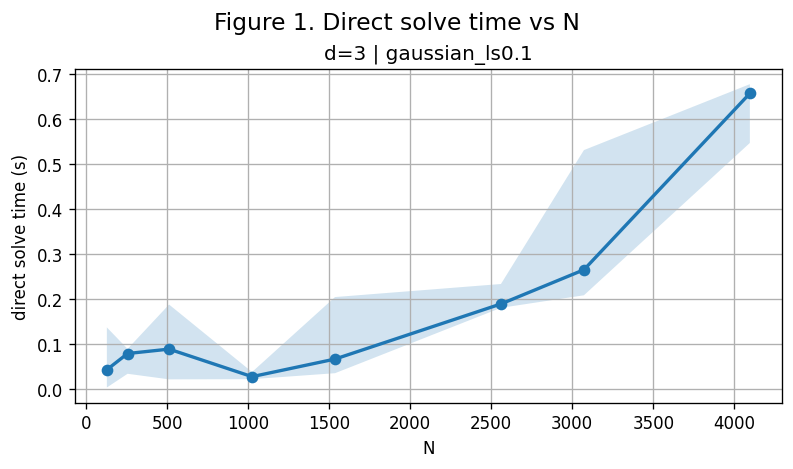

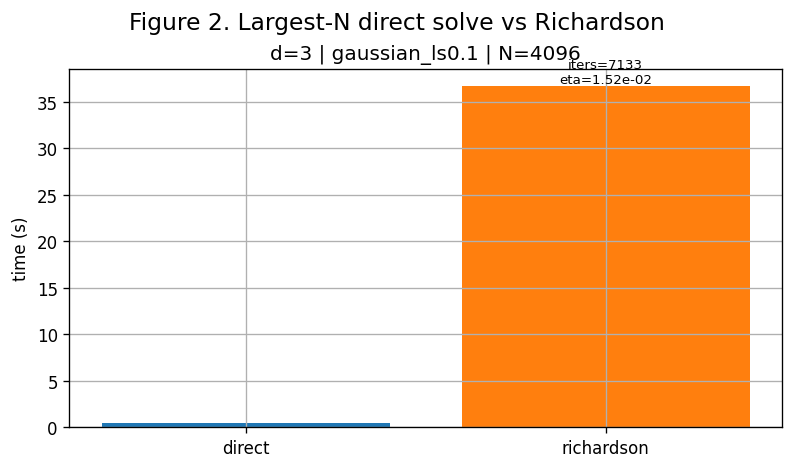

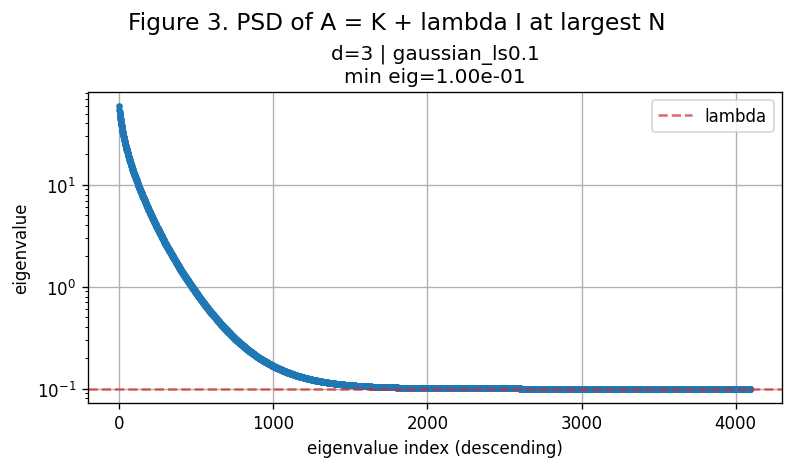

In [ ]:
fig, axes = plt.subplots(
    len(DIM_LIST),
    len(KERNEL_SPECS),
    figsize=subplot_figsize(len(DIM_LIST), len(KERNEL_SPECS), height_per_row=3.3),
    constrained_layout=True,
)
axes = as_axes_2d(axes, len(DIM_LIST), len(KERNEL_SPECS))
for i, dim in enumerate(DIM_LIST):
    if i>1000:
        for j, kernel_cfg in enumerate(KERNEL_SPECS):
            ax = axes[i, j]
            subset = direct_df[
                (direct_df["dim"] == dim) & (direct_df["kernel_name"] == kernel_cfg["name"])
            ].sort_values("N")
            ax.plot(subset["N"], subset["time_s"], marker="o", linewidth=2)
            ax.fill_between(
                subset["N"],
                subset["time_s_mean"] - subset["time_s_std"],
                subset["time_s_mean"] + subset["time_s_std"],
                alpha=0.2,
            )
            ax.set_xscale("log")
            ax.set_xlabel("N")
            ax.set_ylabel("direct solve time (s)")
fig.suptitle("Figure 1. Direct solve via Gaussian Elimination time vs N", fontsize=14)
plt.show()


fig, axes = plt.subplots(
    len(DIM_LIST),
    len(KERNEL_SPECS),
    figsize=subplot_figsize(len(DIM_LIST), len(KERNEL_SPECS), height_per_row=3.2),
    constrained_layout=True,
)
axes = as_axes_2d(axes, len(DIM_LIST), len(KERNEL_SPECS))
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        labels = ["direct", "richardson"]
        values = [case["dense_direct"]["time_s"], case["dense_richardson"]["time_s"]]
        ax.bar(labels, values, color=["tab:blue", "tab:orange"])
        ax.set_ylabel("time (s)")
        ax.text(
            1,
            values[1],
            f"iters={case['dense_richardson']['iters']}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
fig.suptitle("N=4096, direct solve vs Richardson", fontsize=14)
plt.show()

fig, axes = plt.subplots(
    len(DIM_LIST),
    len(KERNEL_SPECS),
    figsize=subplot_figsize(len(DIM_LIST), len(KERNEL_SPECS), height_per_row=3.4),
    constrained_layout=True,
)
axes = as_axes_2d(axes, len(DIM_LIST), len(KERNEL_SPECS))
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        eigvals = np.maximum(case["A_eigvals"], 1e-18)
        ax.semilogy(np.arange(1, eigvals.size + 1), eigvals, marker=".", linewidth=1.25)
        ax.axhline(REG_LAMBDA, linestyle="--", color="tab:red", alpha=0.7, label="lambda")
        ax.set_xscale("log")
        ax.set_xlabel("eigenvalue index (descending)")
        ax.set_ylabel("eigenvalue")
        ax.legend(loc="best")
fig.suptitle("N=4096, Eigenvalue Spectrum of A = K + lambda I at largest N", fontsize=14)
plt.show()

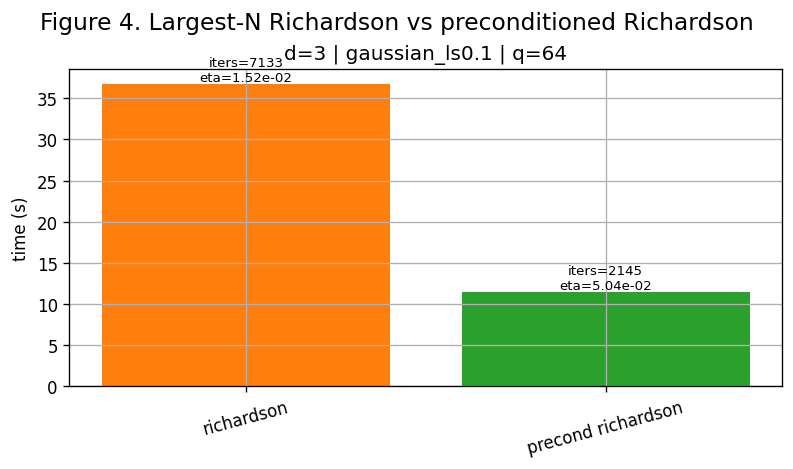

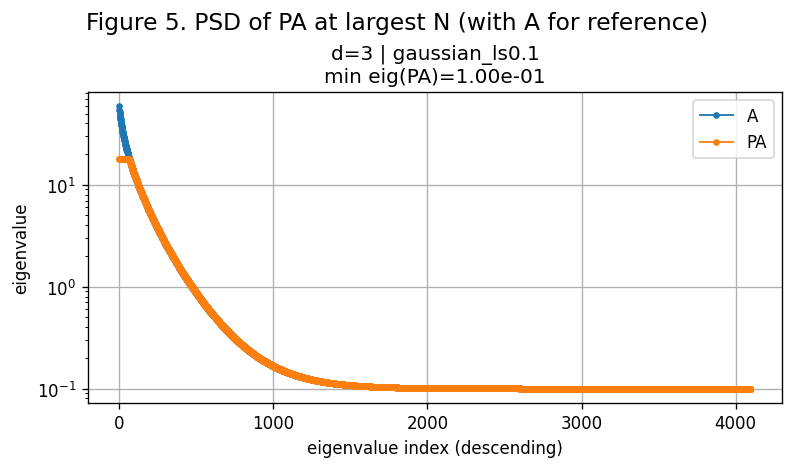

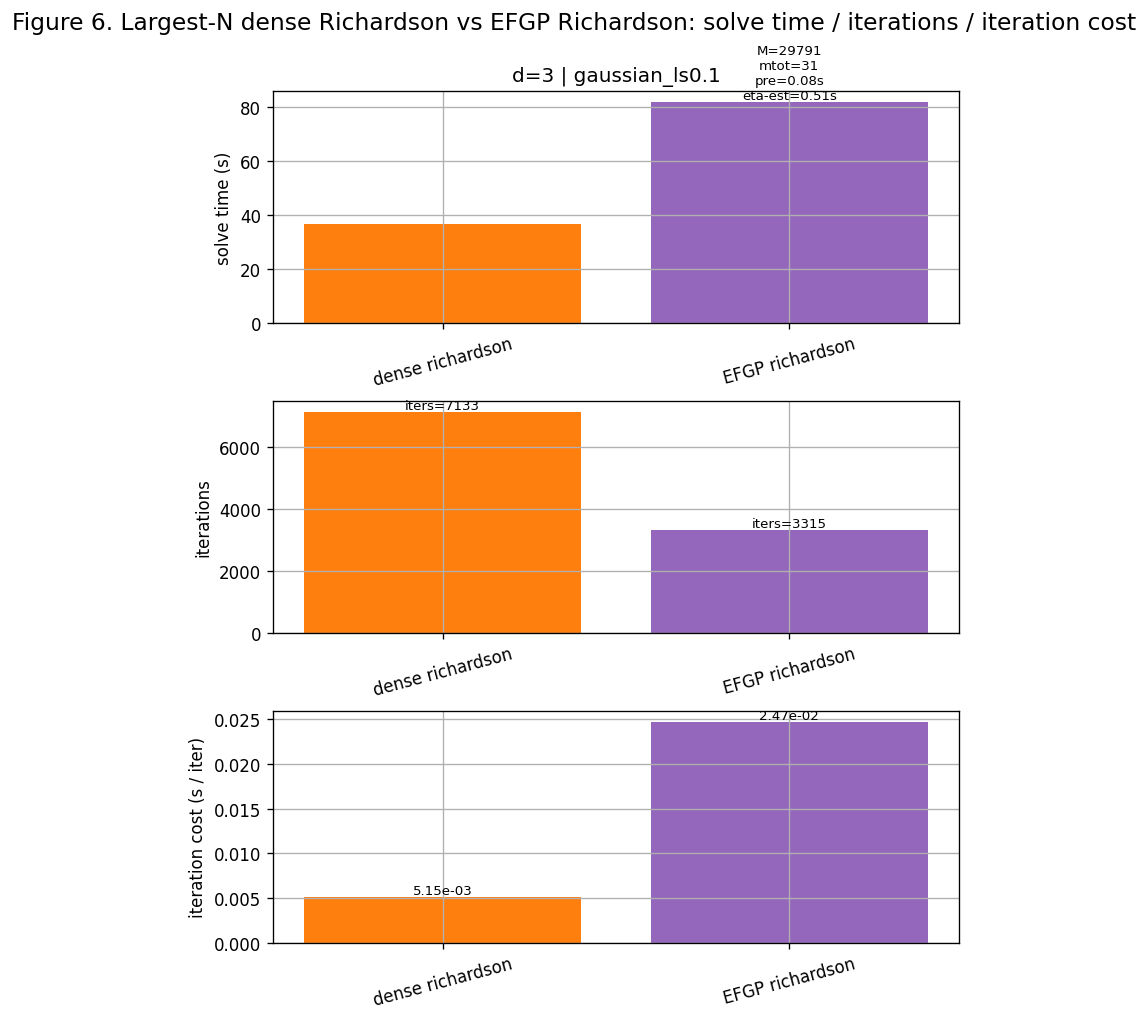

In [ ]:
fig, axes = plt.subplots(
    len(DIM_LIST),
    len(KERNEL_SPECS),
    figsize=subplot_figsize(len(DIM_LIST), len(KERNEL_SPECS), height_per_row=3.2),
    constrained_layout=True,
)
axes = as_axes_2d(axes, len(DIM_LIST), len(KERNEL_SPECS))
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        labels = ["richardson", "precond richardson"]
        values = [
            case["dense_richardson"]["time_s"],
            case["dense_precond_richardson"]["time_s"],
        ]
        ax.bar(labels, values, color=["tab:orange", "tab:green"])
        ax.set_ylabel("time (s)")
        ax.tick_params(axis="x", rotation=15)
        ax.text(
            0,
            values[0],
            f"iters={case['dense_richardson']['iters']}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
        ax.text(
            1,
            values[1],
            f"iters={case['dense_precond_richardson']['iters']}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
fig.suptitle("N=4096 q=64, direct solve vs Richardson", fontsize=14)
plt.show()

fig, axes = plt.subplots(
    len(DIM_LIST),
    len(KERNEL_SPECS),
    figsize=subplot_figsize(len(DIM_LIST), len(KERNEL_SPECS), height_per_row=3.4),
    constrained_layout=True,
)
axes = as_axes_2d(axes, len(DIM_LIST), len(KERNEL_SPECS))
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        a_eigs = np.maximum(case["A_eigvals"], 1e-18)
        pa_eigs = np.maximum(case["PA_eigvals"], 1e-18)
        ax.semilogy(np.arange(1, a_eigs.size + 1), a_eigs, marker=".", linewidth=1.1, label="A")
        ax.semilogy(np.arange(1, pa_eigs.size + 1), pa_eigs, marker=".", linewidth=1.1, label="PA")
        ax.set_xlabel("eigenvalue index (descending)")
        ax.set_ylabel("eigenvalue")
        ax.legend(loc="best")
fig.suptitle("N=4096, Eigenvalue Spectrum of A and PA at largest N", fontsize=14)
plt.show()

metric_specs = [
    ("solve time (s)", lambda case: [case["dense_richardson"]["time_s"], case["efgp_richardson"]["time_solve_s"]]),
    ("iterations", lambda case: [case["dense_richardson"]["iters"], case["efgp_richardson"]["iters"]]),
    (
        "iteration cost (s / iter)",
        lambda case: [
            case["dense_richardson"]["time_s"] / max(case["dense_richardson"]["iters"], 1),
            case["efgp_richardson"]["time_solve_s"] / max(case["efgp_richardson"]["iters"], 1),
        ],
    ),
]

fig, axes = plt.subplots(
    len(DIM_LIST) * len(metric_specs),
    len(KERNEL_SPECS),
    figsize=subplot_figsize(
        len(DIM_LIST) * len(metric_specs),
        len(KERNEL_SPECS),
        width_per_col=5.8,
        height_per_row=2.8,
        min_height=7.5,
        max_height=26.0,
    ),
    constrained_layout=True,
)
axes = as_axes_2d(axes, len(DIM_LIST) * len(metric_specs), len(KERNEL_SPECS))

for i, dim in enumerate(DIM_LIST):
    for m_idx, (ylabel, metric_fn) in enumerate(metric_specs):
        row_idx = i * len(metric_specs) + m_idx
        for j, kernel_cfg in enumerate(KERNEL_SPECS):
            ax = axes[row_idx, j]
            case = largest_case_cache[(dim, kernel_cfg["name"])]
            labels = ["dense richardson", "EFGP richardson"]
            values = metric_fn(case)
            ax.bar(labels, values, color=["tab:orange", "tab:purple"])
            ax.set_ylabel(ylabel)
            ax.tick_params(axis="x", rotation=15)
            if m_idx == 0:
                ax.text(
                    1,
                    values[1],
                    (
                        f"M={case['efgp_richardson']['M']}\n"
                        f"mtot={case['efgp_richardson']['mtot']}\n"
                        f"pre={case['efgp_richardson']['time_precompute_s']:.2f}s\n"
                        f"eta-est={case['efgp_richardson']['time_lambda_est_s']:.2f}s"
                    ),
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
            elif m_idx == 1:
                ax.text(
                    0,
                    values[0],
                    f"iters={case['dense_richardson']['iters']}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
                ax.text(
                    1,
                    values[1],
                    f"iters={case['efgp_richardson']['iters']}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
            else:
                ax.text(
                    0,
                    values[0],
                    f"{values[0]:.2e}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
                ax.text(
                    1,
                    values[1],
                    f"{values[1]:.2e}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

fig.suptitle(
    "Figure 6. Largest-N dense Richardson vs EFGP Richardson: solve time / iterations / iteration cost",
    fontsize=14,
)
plt.show()

Standalone Figure 6 run: N=9000 | use_max=True
[figure6-standalone] d=3 kernel=gaussian_ls0.1 N=9000


,dim,kernel_name,N,dense_solve_s,dense_iters,dense_iter_cost_s,efgp_solve_s,efgp_iters,efgp_iter_cost_s,efgp_precompute_s,efgp_lambda_est_s,efgp_total_s,efgp_M,efgp_mtot
0,3,gaussian_ls0.1,9000,481.667188,15424,0.031228,176.902014,6190,0.028579,0.156727,0.632569,177.69131,29791,31


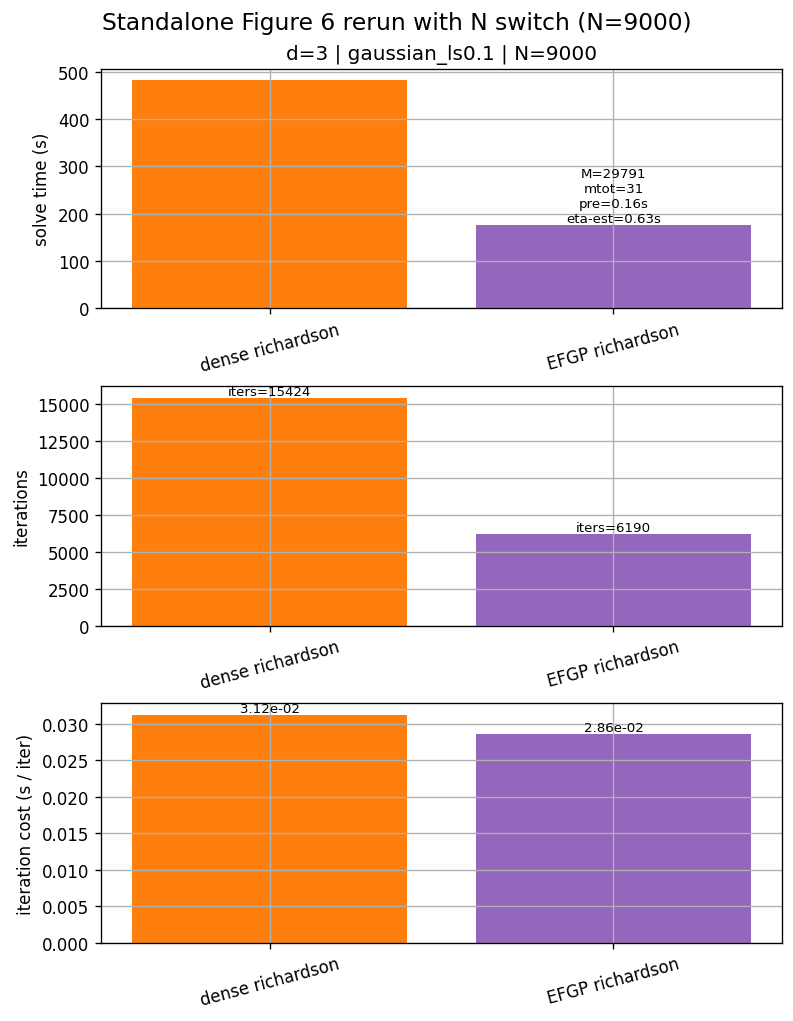

In [ ]:
# Standalone rerun of Figure 6 with an N switch.
# 只需要改下面这几个开关；本单元不依赖前面单元已经执行过的变量。

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _resolve_repo_root_local(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "efgp_eigenpro_py").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing 'efgp_eigenpro_py'.")


_REPO_ROOT_LOCAL = _resolve_repo_root_local()
if str(_REPO_ROOT_LOCAL) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT_LOCAL))

from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.eigenspace import estimate_top_eigenspace
from efgp_eigenpro_py.kernels import make_matern, make_squared_exponential
from efgp_eigenpro_py.linear_solvers import richardson


# =========================
# User switches
# =========================
FIG6_DIM_LIST = [3]
FIG6_N_CANDIDATES = [800, 1600,3200,6400,9600, 12800]
FIG6_USE_MAX_N = True   # True: 用上面列表里的最大 N；False: 用 FIG6_N_OVERRIDE
FIG6_N_OVERRIDE = 1024

FIG6_KERNEL_SPECS = [
    {
        "name": "gaussian_ls0.1",
        "family": "gaussian",
        "lengthscale": 0.1,
        "variance": 1.0,
    },
]

FIG6_NOISE_STD = 0.05
FIG6_REG_LAMBDA = 0.1
FIG6_RICHARDSON_TOL = 1e-6
FIG6_RICHARDSON_MAXITER = 100000
FIG6_EFGP_EPS = 1e-1
FIG6_EFGP_NUFFT_TOL = 1e-10
FIG6_EFGP_L2_SCALED = True
FIG6_EFGP_LAMBDA_EST_METHOD = "subspace_iter"
FIG6_EFGP_LAMBDA_EST_MAXITER = 4
FIG6_GLOBAL_SEED = 20260511


# =========================
# Local helpers
# =========================

def _fig6_as_axes_2d(axes, nrows: int, ncols: int) -> np.ndarray:
    axes_arr = np.asarray(axes, dtype=object)
    if axes_arr.ndim == 0:
        return axes_arr.reshape(1, 1)
    if axes_arr.ndim == 1:
        if int(nrows) == 1:
            return axes_arr.reshape(1, int(ncols))
        if int(ncols) == 1:
            return axes_arr.reshape(int(nrows), 1)
    return axes_arr


def _fig6_subplot_figsize(
    nrows: int,
    ncols: int,
    *,
    width_per_col: float = 5.8,
    height_per_row: float = 2.8,
    min_width: float = 6.5,
    min_height: float = 7.5,
    max_width: float = 16.0,
    max_height: float = 26.0,
) -> tuple[float, float]:
    width = min(max(float(ncols) * width_per_col, min_width), max_width)
    height = min(max(float(nrows) * height_per_row, min_height), max_height)
    return width, height


def _fig6_omega_for_dim(dim: int) -> np.ndarray:
    omega = np.arange(1, dim + 1, dtype=np.float64)
    omega /= np.linalg.norm(omega)
    return omega


def _fig6_target_function(x: np.ndarray, omega: np.ndarray, phase: float = 1.3) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    return np.cos(2.0 * np.pi * (x @ omega) + float(phase))


def _fig6_generate_dataset(dim: int, n: int, noise_std: float, seed: int) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(int(seed))
    omega = _fig6_omega_for_dim(dim)
    x_train = rng.uniform(0.0, 1.0, size=(int(n), int(dim)))
    y_true = _fig6_target_function(x_train, omega)
    y_train = y_true + rng.normal(0.0, float(noise_std), size=int(n))
    return np.asarray(x_train, dtype=np.float64), np.asarray(y_train, dtype=np.float64)


def _fig6_pairwise_distance_matrix(x1: np.ndarray, x2: np.ndarray | None = None) -> np.ndarray:
    x1 = np.asarray(x1, dtype=np.float64)
    x2 = x1 if x2 is None else np.asarray(x2, dtype=np.float64)
    diff = x1[:, None, :] - x2[None, :, :]
    return np.linalg.norm(diff, axis=-1)


def _fig6_make_kernel(kernel_cfg: dict, dim: int):
    family = str(kernel_cfg.get("family", "matern")).strip().lower()
    lengthscale = float(kernel_cfg["lengthscale"])
    variance = float(kernel_cfg.get("variance", 1.0))
    if family in {"matern", "mat", "mat32", "mat52"}:
        return make_matern(
            lengthscale=lengthscale,
            nu=float(kernel_cfg.get("nu", 1.5)),
            dim=int(dim),
            variance=variance,
        )
    if family in {"gaussian", "rbf", "se", "squared_exponential", "squared-exponential"}:
        return make_squared_exponential(lengthscale=lengthscale, dim=int(dim), variance=variance)
    raise ValueError(f"Unsupported kernel family: {family}")


def _fig6_build_dense_system(x_train: np.ndarray, y_train: np.ndarray, kernel_cfg: dict):
    kernel = _fig6_make_kernel(kernel_cfg, x_train.shape[1])
    K = np.asarray(kernel.k(_fig6_pairwise_distance_matrix(x_train)), dtype=np.float64)
    A = K + float(FIG6_REG_LAMBDA) * np.eye(x_train.shape[0], dtype=np.float64)
    b = np.asarray(y_train, dtype=np.float64).reshape(-1)
    return A, b


def _fig6_richardson_eta(lambda_max: float, safety: float = 0.9) -> float:
    return float(safety) / max(float(lambda_max), 1e-12)


def _fig6_run_dense_richardson(A: np.ndarray, b: np.ndarray) -> dict:
    eigvals = np.linalg.eigvalsh(A)
    lambda_max = float(np.max(eigvals))
    eta = _fig6_richardson_eta(lambda_max)
    x0 = np.zeros_like(b)
    t0 = time.perf_counter()
    alpha, iters, relres = richardson(
        lambda v: A @ v,
        b,
        x0,
        eta=eta,
        tol=FIG6_RICHARDSON_TOL,
        maxiter=FIG6_RICHARDSON_MAXITER,
    )
    t1 = time.perf_counter()
    return {
        "alpha": alpha,
        "iters": int(iters),
        "eta": float(eta),
        "relres": float(relres),
        "time_s": float(t1 - t0),
        "iter_cost_s": float(t1 - t0) / max(int(iters), 1),
    }


def _fig6_estimate_efgp_lambda_max(solver: EFGPSolver, state) -> float:
    eigpairs = estimate_top_eigenspace(
        lambda v: solver._apply_A(state, v),
        size=int(state.rhs.size),
        top_q=1,
        method=FIG6_EFGP_LAMBDA_EST_METHOD,
        maxiter=FIG6_EFGP_LAMBDA_EST_MAXITER,
        matvec_block=lambda V: solver._apply_A_block(state, V),
        block_size=4,
        oversample=1,
    )
    return float(np.real(eigpairs.values[0]))


def _fig6_run_efgp_richardson(x_train: np.ndarray, y_train: np.ndarray, kernel_cfg: dict) -> dict:
    kernel = _fig6_make_kernel(kernel_cfg, x_train.shape[1])
    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=FIG6_REG_LAMBDA,
        eps=FIG6_EFGP_EPS,
        nufft_tol=FIG6_EFGP_NUFFT_TOL,
        l2scaled=FIG6_EFGP_L2_SCALED,
    )

    t0 = time.perf_counter()
    state = solver.precompute(x_train, y_train)
    t1 = time.perf_counter()

    lambda_max = _fig6_estimate_efgp_lambda_max(solver, state)
    eta = _fig6_richardson_eta(lambda_max)
    beta0 = np.zeros_like(state.rhs)

    t2 = time.perf_counter()
    beta, iters, relres = richardson(
        lambda v: solver._apply_A(state, v),
        state.rhs,
        beta0,
        eta=eta,
        tol=FIG6_RICHARDSON_TOL,
        maxiter=FIG6_RICHARDSON_MAXITER,
    )
    t3 = time.perf_counter()

    return {
        "beta": beta,
        "iters": int(iters),
        "eta": float(eta),
        "relres": float(relres),
        "lambda_max_est": float(lambda_max),
        "M": int(state.rhs.size),
        "mtot": int(state.grid.mtot),
        "time_precompute_s": float(t1 - t0),
        "time_lambda_est_s": float(t2 - t1),
        "time_solve_s": float(t3 - t2),
        "time_total_s": float(t3 - t0),
        "iter_cost_s": float(t3 - t2) / max(int(iters), 1),
    }


# =========================
# Run standalone Figure 6
# =========================
FIG6_SELECTED_N = max(FIG6_N_CANDIDATES) if FIG6_USE_MAX_N else int(FIG6_N_OVERRIDE)
print(f"Standalone Figure 6 run: N={FIG6_SELECTED_N} | use_max={FIG6_USE_MAX_N}")

fig6_rows: list[dict] = []
fig6_case_cache: dict[tuple[int, str], dict] = {}

for dim in FIG6_DIM_LIST:
    x_train, y_train = _fig6_generate_dataset(dim, FIG6_SELECTED_N, FIG6_NOISE_STD, FIG6_GLOBAL_SEED + dim)
    for kernel_cfg in FIG6_KERNEL_SPECS:
        kernel_name = str(kernel_cfg["name"])
        print(f"[figure6-standalone] d={dim} kernel={kernel_name} N={FIG6_SELECTED_N}")
        A, b = _fig6_build_dense_system(x_train, y_train, kernel_cfg)
        dense_case = _fig6_run_dense_richardson(A, b)
        efgp_case = _fig6_run_efgp_richardson(x_train, y_train, kernel_cfg)
        key = (int(dim), kernel_name)
        fig6_case_cache[key] = {
            "dim": int(dim),
            "kernel_name": kernel_name,
            "N": int(FIG6_SELECTED_N),
            "dense": dense_case,
            "efgp": efgp_case,
        }
        fig6_rows.append(
            {
                "dim": int(dim),
                "kernel_name": kernel_name,
                "N": int(FIG6_SELECTED_N),
                "dense_solve_s": float(dense_case["time_s"]),
                "dense_iters": int(dense_case["iters"]),
                "dense_iter_cost_s": float(dense_case["iter_cost_s"]),
                "efgp_solve_s": float(efgp_case["time_solve_s"]),
                "efgp_iters": int(efgp_case["iters"]),
                "efgp_iter_cost_s": float(efgp_case["iter_cost_s"]),
                "efgp_precompute_s": float(efgp_case["time_precompute_s"]),
                "efgp_lambda_est_s": float(efgp_case["time_lambda_est_s"]),
                "efgp_total_s": float(efgp_case["time_total_s"]),
                "efgp_M": int(efgp_case["M"]),
                "efgp_mtot": int(efgp_case["mtot"]),
            }
        )

fig6_df = pd.DataFrame(fig6_rows).sort_values(["dim", "kernel_name"]).reset_index(drop=True)
display(fig6_df)

fig6_metric_specs = [
    ("solve time (s)", lambda case: [case["dense"]["time_s"], case["efgp"]["time_solve_s"]]),
    ("iterations", lambda case: [case["dense"]["iters"], case["efgp"]["iters"]]),
    ("iteration cost (s / iter)", lambda case: [case["dense"]["iter_cost_s"], case["efgp"]["iter_cost_s"]]),
]

fig, axes = plt.subplots(
    len(FIG6_DIM_LIST) * len(fig6_metric_specs),
    len(FIG6_KERNEL_SPECS),
    figsize=_fig6_subplot_figsize(
        len(FIG6_DIM_LIST) * len(fig6_metric_specs),
        len(FIG6_KERNEL_SPECS),
        width_per_col=5.8,
        height_per_row=2.8,
        min_height=7.5,
        max_height=26.0,
    ),
    constrained_layout=True,
)
axes = _fig6_as_axes_2d(axes, len(FIG6_DIM_LIST) * len(fig6_metric_specs), len(FIG6_KERNEL_SPECS))

for i, dim in enumerate(FIG6_DIM_LIST):
    for m_idx, (ylabel, metric_fn) in enumerate(fig6_metric_specs):
        row_idx = i * len(fig6_metric_specs) + m_idx
        for j, kernel_cfg in enumerate(FIG6_KERNEL_SPECS):
            ax = axes[row_idx, j]
            case = fig6_case_cache[(dim, kernel_cfg["name"])]
            labels = ["dense richardson", "EFGP richardson"]
            values = metric_fn(case)
            ax.bar(labels, values, color=["tab:orange", "tab:purple"])
            ax.set_ylabel(ylabel)
            ax.tick_params(axis="x", rotation=15)
            if m_idx == 0:
                ax.text(
                    1,
                    values[1],
                    (
                        f"M={case['efgp']['M']}\n"
                        f"mtot={case['efgp']['mtot']}\n"
                        f"pre={case['efgp']['time_precompute_s']:.2f}s\n"
                        f"eta-est={case['efgp']['time_lambda_est_s']:.2f}s"
                    ),
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
            elif m_idx == 1:
                ax.text(0, values[0], f"iters={case['dense']['iters']}", ha="center", va="bottom", fontsize=8)
                ax.text(1, values[1], f"iters={case['efgp']['iters']}", ha="center", va="bottom", fontsize=8)
            else:
                ax.text(0, values[0], f"{values[0]:.2e}", ha="center", va="bottom", fontsize=8)
                ax.text(1, values[1], f"{values[1]:.2e}", ha="center", va="bottom", fontsize=8)

fig.suptitle(
    f"Standalone Figure 6 rerun with N switch (N={FIG6_SELECTED_N})",
    fontsize=14,
)
plt.show()

Standalone Figure 6 N sweep: [100, 200, 400, 800, 1600, 3200]
[figure6-n-sweep] d=3 kernel=gaussian_ls0.1 N=100
[figure6-n-sweep] d=3 kernel=gaussian_ls0.1 N=200
[figure6-n-sweep] d=3 kernel=gaussian_ls0.1 N=400
[figure6-n-sweep] d=3 kernel=gaussian_ls0.1 N=800
[figure6-n-sweep] d=3 kernel=gaussian_ls0.1 N=1600
[figure6-n-sweep] d=3 kernel=gaussian_ls0.1 N=3200


,dim,kernel_name,N,dense_train_time_s,dense_iterations,dense_iteration_cost_s,efgp_train_time_s,efgp_iterations,efgp_iteration_cost_s,dense_solve_time_s,efgp_solve_time_s,efgp_precompute_s,efgp_lambda_est_s,efgp_M,efgp_mtot
0,3,gaussian_ls0.1,100,0.023616,208,0.000108,1.844233,168,0.009187,0.022417,1.543384,0.063581,0.237267,24389,29
1,3,gaussian_ls0.1,200,0.046309,394,0.000103,2.756807,279,0.008929,0.040538,2.491266,0.045103,0.220439,24389,29
2,3,gaussian_ls0.1,400,0.137077,863,0.000120,5.271332,563,0.008844,0.103487,4.979103,0.067443,0.224785,24389,29
3,3,gaussian_ls0.1,800,0.409713,1530,0.000147,10.635702,944,0.010977,0.224978,10.362630,0.049441,0.223632,24389,29
4,3,gaussian_ls0.1,1600,2.438938,3071,0.000564,19.039588,1717,0.010894,1.730709,18.704606,0.061384,0.273598,24389,29
5,3,gaussian_ls0.1,3200,22.150984,5467,0.003377,29.089153,2733,0.010513,18.461093,28.731392,0.062276,0.295484,24389,29


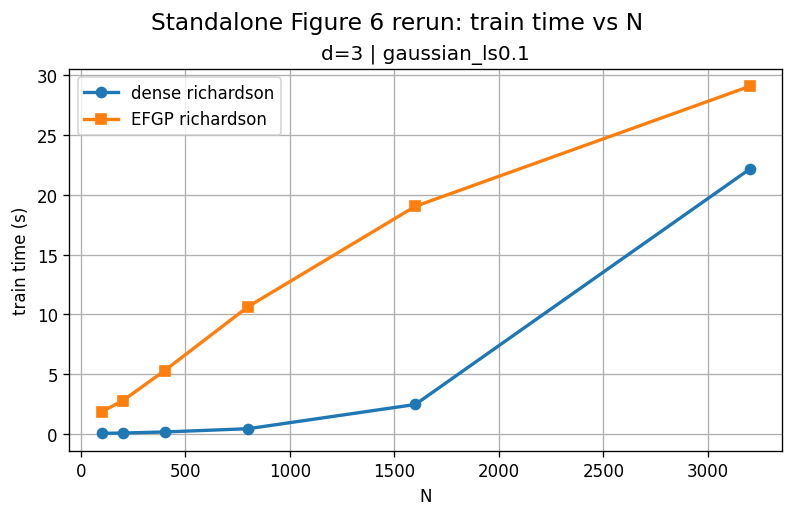

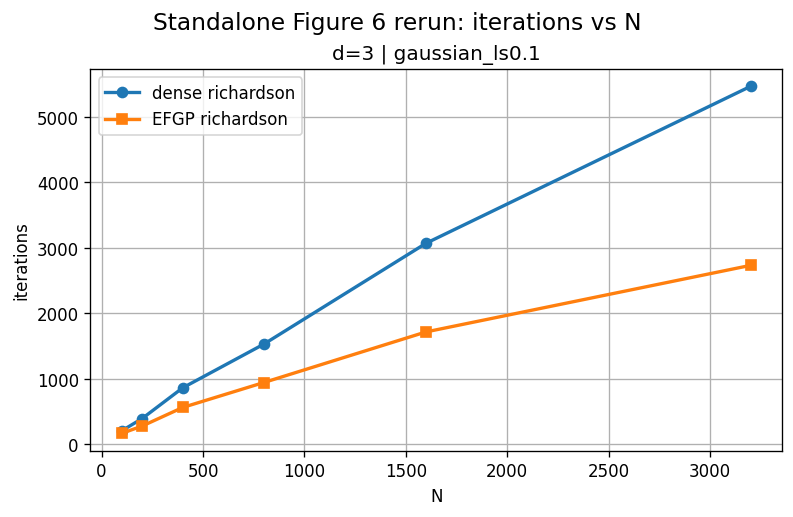

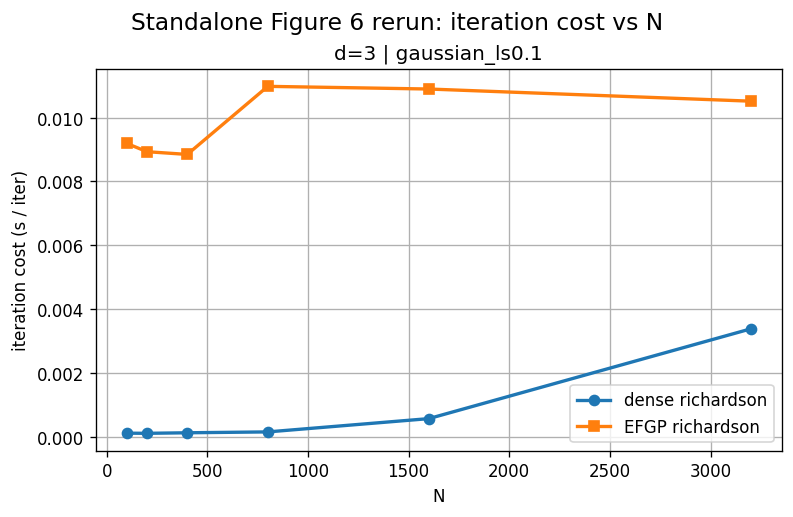

In [ ]:
# Standalone N-sweep rerun of Figure 6.
# 这个单元不依赖前面变量；会输出 3 张折线图：train time / iterations / iteration cost vs N。
# 这里把原来的 solve time 改成 train time：
# - dense: build A + lambda_max prep + Richardson solve
# - EFGP : precompute + lambda_max prep + Richardson solve

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _resolve_repo_root_local_v2(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "efgp_eigenpro_py").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing 'efgp_eigenpro_py'.")


_REPO_ROOT_LOCAL_V2 = _resolve_repo_root_local_v2()
if str(_REPO_ROOT_LOCAL_V2) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT_LOCAL_V2))

from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.eigenspace import estimate_top_eigenspace
from efgp_eigenpro_py.kernels import make_matern, make_squared_exponential
from efgp_eigenpro_py.linear_solvers import richardson


# =========================
# User switches
# =========================
FIG6S_DIM_LIST = [3]
FIG6S_N_CANDIDATES = [800, 1600, 3200,6400,9600,12800]
FIG6S_USE_CANDIDATE_LIST = True
FIG6S_N_OVERRIDE_LIST = [800, 1600, 3200]

FIG6S_KERNEL_SPECS = [
    {
        "name": "gaussian_ls0.1",
        "family": "gaussian",
        "lengthscale": 0.1,
        "variance": 1.0,
    },
]

FIG6S_NOISE_STD = 0.05
FIG6S_REG_LAMBDA = 0.1
FIG6S_RICHARDSON_TOL = 1e-6
FIG6S_RICHARDSON_MAXITER = 100000
FIG6S_EFGP_EPS = 1e-1
FIG6S_EFGP_NUFFT_TOL = 1e-10
FIG6S_EFGP_L2_SCALED = True
FIG6S_EFGP_LAMBDA_EST_METHOD = "subspace_iter"
FIG6S_EFGP_LAMBDA_EST_MAXITER = 4
FIG6S_GLOBAL_SEED = 20260511


# =========================
# Local helpers
# =========================

def _fig6s_as_axes_2d(axes, nrows: int, ncols: int) -> np.ndarray:
    axes_arr = np.asarray(axes, dtype=object)
    if axes_arr.ndim == 0:
        return axes_arr.reshape(1, 1)
    if axes_arr.ndim == 1:
        if int(nrows) == 1:
            return axes_arr.reshape(1, int(ncols))
        if int(ncols) == 1:
            return axes_arr.reshape(int(nrows), 1)
    return axes_arr


def _fig6s_subplot_figsize(
    nrows: int,
    ncols: int,
    *,
    width_per_col: float = 5.8,
    height_per_row: float = 3.2,
    min_width: float = 6.5,
    min_height: float = 4.2,
    max_width: float = 16.0,
    max_height: float = 16.0,
) -> tuple[float, float]:
    width = min(max(float(ncols) * width_per_col, min_width), max_width)
    height = min(max(float(nrows) * height_per_row, min_height), max_height)
    return width, height


def _fig6s_omega_for_dim(dim: int) -> np.ndarray:
    omega = np.arange(1, dim + 1, dtype=np.float64)
    omega /= np.linalg.norm(omega)
    return omega


def _fig6s_target_function(x: np.ndarray, omega: np.ndarray, phase: float = 1.3) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    return np.cos(2.0 * np.pi * (x @ omega) + float(phase))


def _fig6s_generate_dataset(dim: int, n: int, noise_std: float, seed: int) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(int(seed))
    omega = _fig6s_omega_for_dim(dim)
    x_train = rng.uniform(0.0, 1.0, size=(int(n), int(dim)))
    y_true = _fig6s_target_function(x_train, omega)
    y_train = y_true + rng.normal(0.0, float(noise_std), size=int(n))
    return np.asarray(x_train, dtype=np.float64), np.asarray(y_train, dtype=np.float64)


def _fig6s_pairwise_distance_matrix(x1: np.ndarray, x2: np.ndarray | None = None) -> np.ndarray:
    x1 = np.asarray(x1, dtype=np.float64)
    x2 = x1 if x2 is None else np.asarray(x2, dtype=np.float64)
    diff = x1[:, None, :] - x2[None, :, :]
    return np.linalg.norm(diff, axis=-1)


def _fig6s_make_kernel(kernel_cfg: dict, dim: int):
    family = str(kernel_cfg.get("family", "matern")).strip().lower()
    lengthscale = float(kernel_cfg["lengthscale"])
    variance = float(kernel_cfg.get("variance", 1.0))
    if family in {"matern", "mat", "mat32", "mat52"}:
        return make_matern(
            lengthscale=lengthscale,
            nu=float(kernel_cfg.get("nu", 1.5)),
            dim=int(dim),
            variance=variance,
        )
    if family in {"gaussian", "rbf", "se", "squared_exponential", "squared-exponential"}:
        return make_squared_exponential(lengthscale=lengthscale, dim=int(dim), variance=variance)
    raise ValueError(f"Unsupported kernel family: {family}")


def _fig6s_build_dense_system(x_train: np.ndarray, y_train: np.ndarray, kernel_cfg: dict) -> tuple[np.ndarray, np.ndarray]:
    kernel = _fig6s_make_kernel(kernel_cfg, x_train.shape[1])
    K = np.asarray(kernel.k(_fig6s_pairwise_distance_matrix(x_train)), dtype=np.float64)
    A = K + float(FIG6S_REG_LAMBDA) * np.eye(x_train.shape[0], dtype=np.float64)
    b = np.asarray(y_train, dtype=np.float64).reshape(-1)
    return A, b


def _fig6s_richardson_eta(lambda_max: float, safety: float = 0.9) -> float:
    return float(safety) / max(float(lambda_max), 1e-12)


def _fig6s_run_dense_training(x_train: np.ndarray, y_train: np.ndarray, kernel_cfg: dict) -> dict:
    t0 = time.perf_counter()
    A, b = _fig6s_build_dense_system(x_train, y_train, kernel_cfg)
    t1 = time.perf_counter()

    eigvals = np.linalg.eigvalsh(A)
    lambda_max = float(np.max(eigvals))
    eta = _fig6s_richardson_eta(lambda_max)
    alpha0 = np.zeros_like(b)
    t2 = time.perf_counter()

    alpha, iters, relres = richardson(
        lambda v: A @ v,
        b,
        alpha0,
        eta=eta,
        tol=FIG6S_RICHARDSON_TOL,
        maxiter=FIG6S_RICHARDSON_MAXITER,
    )
    t3 = time.perf_counter()

    return {
        "alpha": alpha,
        "iters": int(iters),
        "eta": float(eta),
        "relres": float(relres),
        "time_build_s": float(t1 - t0),
        "time_lambda_est_s": float(t2 - t1),
        "time_solve_s": float(t3 - t2),
        "train_time_s": float(t3 - t0),
        "iter_cost_s": float(t3 - t2) / max(int(iters), 1),
    }


def _fig6s_estimate_efgp_lambda_max(solver: EFGPSolver, state) -> float:
    eigpairs = estimate_top_eigenspace(
        lambda v: solver._apply_A(state, v),
        size=int(state.rhs.size),
        top_q=1,
        method=FIG6S_EFGP_LAMBDA_EST_METHOD,
        maxiter=FIG6S_EFGP_LAMBDA_EST_MAXITER,
        matvec_block=lambda V: solver._apply_A_block(state, V),
        block_size=4,
        oversample=1,
    )
    return float(np.real(eigpairs.values[0]))


def _fig6s_run_efgp_training(x_train: np.ndarray, y_train: np.ndarray, kernel_cfg: dict) -> dict:
    kernel = _fig6s_make_kernel(kernel_cfg, x_train.shape[1])
    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=FIG6S_REG_LAMBDA,
        eps=FIG6S_EFGP_EPS,
        nufft_tol=FIG6S_EFGP_NUFFT_TOL,
        l2scaled=FIG6S_EFGP_L2_SCALED,
    )

    t0 = time.perf_counter()
    state = solver.precompute(x_train, y_train)
    t1 = time.perf_counter()

    lambda_max = _fig6s_estimate_efgp_lambda_max(solver, state)
    eta = _fig6s_richardson_eta(lambda_max)
    beta0 = np.zeros_like(state.rhs)
    t2 = time.perf_counter()

    beta, iters, relres = richardson(
        lambda v: solver._apply_A(state, v),
        state.rhs,
        beta0,
        eta=eta,
        tol=FIG6S_RICHARDSON_TOL,
        maxiter=FIG6S_RICHARDSON_MAXITER,
    )
    t3 = time.perf_counter()

    return {
        "beta": beta,
        "iters": int(iters),
        "eta": float(eta),
        "relres": float(relres),
        "M": int(state.rhs.size),
        "mtot": int(state.grid.mtot),
        "time_precompute_s": float(t1 - t0),
        "time_lambda_est_s": float(t2 - t1),
        "time_solve_s": float(t3 - t2),
        "train_time_s": float(t3 - t0),
        "iter_cost_s": float(t3 - t2) / max(int(iters), 1),
    }


def _fig6s_plot_metric(df: pd.DataFrame, metric_dense: str, metric_efgp: str, ylabel: str, title: str) -> None:
    nrows = len(FIG6S_DIM_LIST)
    ncols = len(FIG6S_KERNEL_SPECS)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=_fig6s_subplot_figsize(nrows, ncols),
        constrained_layout=True,
    )
    axes = _fig6s_as_axes_2d(axes, nrows, ncols)

    for i, dim in enumerate(FIG6S_DIM_LIST):
        for j, kernel_cfg in enumerate(FIG6S_KERNEL_SPECS):
            ax = axes[i, j]
            subset = df[
                (df["dim"] == int(dim)) & (df["kernel_name"] == str(kernel_cfg["name"]))
            ].sort_values("N")
            ax.plot(subset["N"], subset[metric_dense], marker="o", linewidth=2, label="dense richardson")
            ax.plot(subset["N"], subset[metric_efgp], marker="s", linewidth=2, label="EFGP richardson")
            ax.set_xscale("log")
            ax.set_xlabel("N")
            ax.set_ylabel(ylabel)
            ax.legend(loc="best")

    fig.suptitle(title, fontsize=14)
    plt.show()


# =========================
# Run standalone Figure 6 N sweep
# =========================
FIG6S_SELECTED_NS = FIG6S_N_CANDIDATES if FIG6S_USE_CANDIDATE_LIST else FIG6S_N_OVERRIDE_LIST
FIG6S_SELECTED_NS = sorted({int(n) for n in FIG6S_SELECTED_NS if int(n) > 0})
if not FIG6S_SELECTED_NS:
    raise ValueError("FIG6S_SELECTED_NS is empty.")

print("Standalone Figure 6 N sweep:", FIG6S_SELECTED_NS)

fig6s_rows: list[dict] = []

for dim in FIG6S_DIM_LIST:
    for n in FIG6S_SELECTED_NS:
        x_train, y_train = _fig6s_generate_dataset(dim, n, FIG6S_NOISE_STD, FIG6S_GLOBAL_SEED + dim + 1000 * n)
        for kernel_cfg in FIG6S_KERNEL_SPECS:
            kernel_name = str(kernel_cfg["name"])
            print(f"[figure6-n-sweep] d={dim} kernel={kernel_name} N={n}")
            dense_case = _fig6s_run_dense_training(x_train, y_train, kernel_cfg)
            efgp_case = _fig6s_run_efgp_training(x_train, y_train, kernel_cfg)
            fig6s_rows.append(
                {
                    "dim": int(dim),
                    "kernel_name": kernel_name,
                    "N": int(n),
                    "dense_train_time_s": float(dense_case["train_time_s"]),
                    "dense_iterations": int(dense_case["iters"]),
                    "dense_iteration_cost_s": float(dense_case["iter_cost_s"]),
                    "efgp_train_time_s": float(efgp_case["train_time_s"]),
                    "efgp_iterations": int(efgp_case["iters"]),
                    "efgp_iteration_cost_s": float(efgp_case["iter_cost_s"]),
                    "dense_solve_time_s": float(dense_case["time_solve_s"]),
                    "efgp_solve_time_s": float(efgp_case["time_solve_s"]),
                    "efgp_precompute_s": float(efgp_case["time_precompute_s"]),
                    "efgp_lambda_est_s": float(efgp_case["time_lambda_est_s"]),
                    "efgp_M": int(efgp_case["M"]),
                    "efgp_mtot": int(efgp_case["mtot"]),
                }
            )

fig6s_df = pd.DataFrame(fig6s_rows).sort_values(["dim", "kernel_name", "N"]).reset_index(drop=True)
display(fig6s_df)

_fig6s_plot_metric(
    fig6s_df,
    metric_dense="dense_train_time_s",
    metric_efgp="efgp_train_time_s",
    ylabel="train time (s)",
    title="Scalability Comparison of Richardson vs. EFGP Richardson Solvers",
)

_fig6s_plot_metric(
    fig6s_df,
    metric_dense="dense_iterations",
    metric_efgp="efgp_iterations",
    ylabel="iterations",
    title="Convergence Rate Comparison: Iteration Count vs. N",
)

_fig6s_plot_metric(
    fig6s_df,
    metric_dense="dense_iteration_cost_s",
    metric_efgp="efgp_iteration_cost_s",
    ylabel="iteration cost (s / iter)",
    title="Scalability of Iterative Step Complexity",
)